# Module B Report: Web Application & Secure API

## 1. System Architecture & Methodology
The CareerTrack Placement Management System successfully transitions our conceptual relational database design into a production-ready Web Application. The system is built using a decoupled **Three-Tier Architecture**:
* **Presentation Layer:** Dynamic HTML/CSS templates rendering the frontend UI.
* **Application Layer:** A **Flask (Python)** backend handling business logic, session routing, and API endpoints.
* **Database Layer:** An **SQLite3** relational database ensuring secure, persistent data storage.

---

![Screenshot 2026-03-22 162935.png](<attachment:Screenshot 2026-03-22 162935.png>)
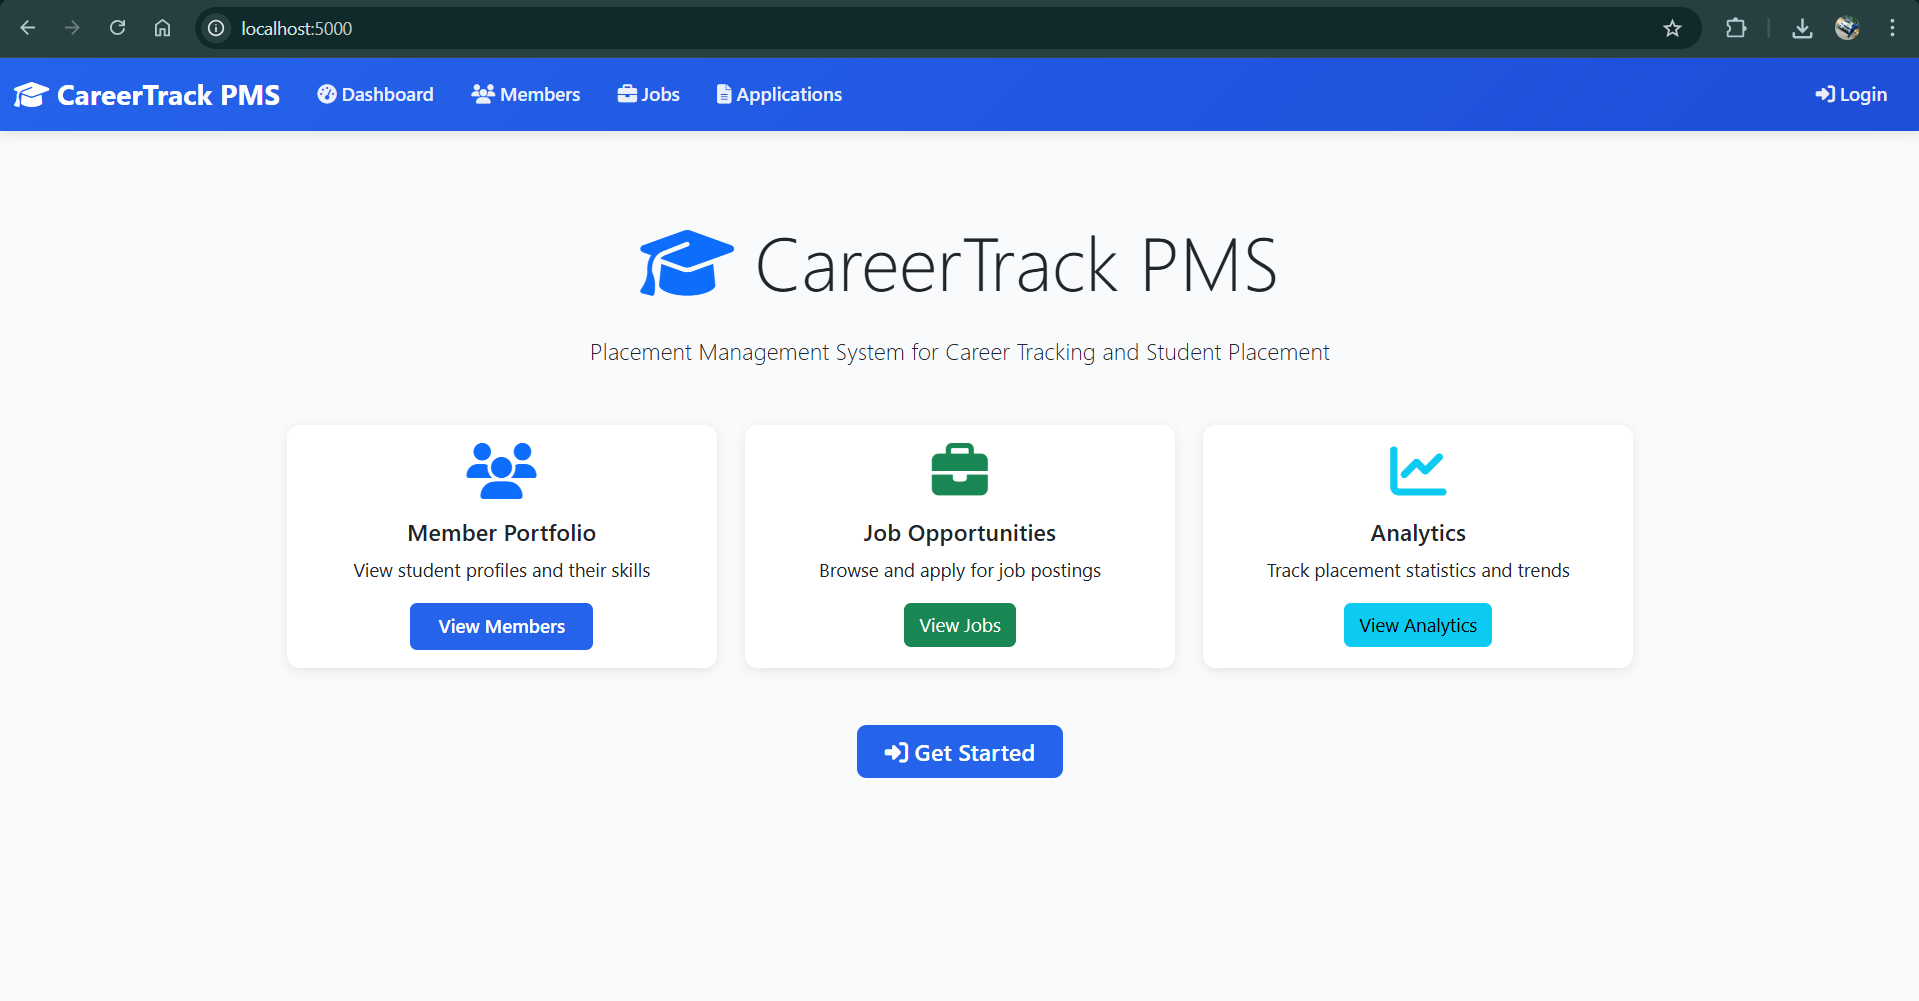

## 2. Database Schema & Modular Initialization
To maintain a clean and scalable environment, we modularized our database initialization process into three distinct phases. This ensures the database can be rebuilt or migrated seamlessly:
1. `core_tables.sql`: Defines the normalized schema (1NF, 2NF, 3NF), enforcing Primary Keys, Foreign Keys, and strict referential integrity (cascading deletes).
2. `project_dump.sql`: Populates the tables with synthetic, project-specific data to simulate a live placement cycle.
3. `indexes.sql`: Applies the B-Tree indexing layer to high-traffic columns.

---

![Screenshot 2026-03-22 163555.png](<attachment:Screenshot 2026-03-22 163555.png>)
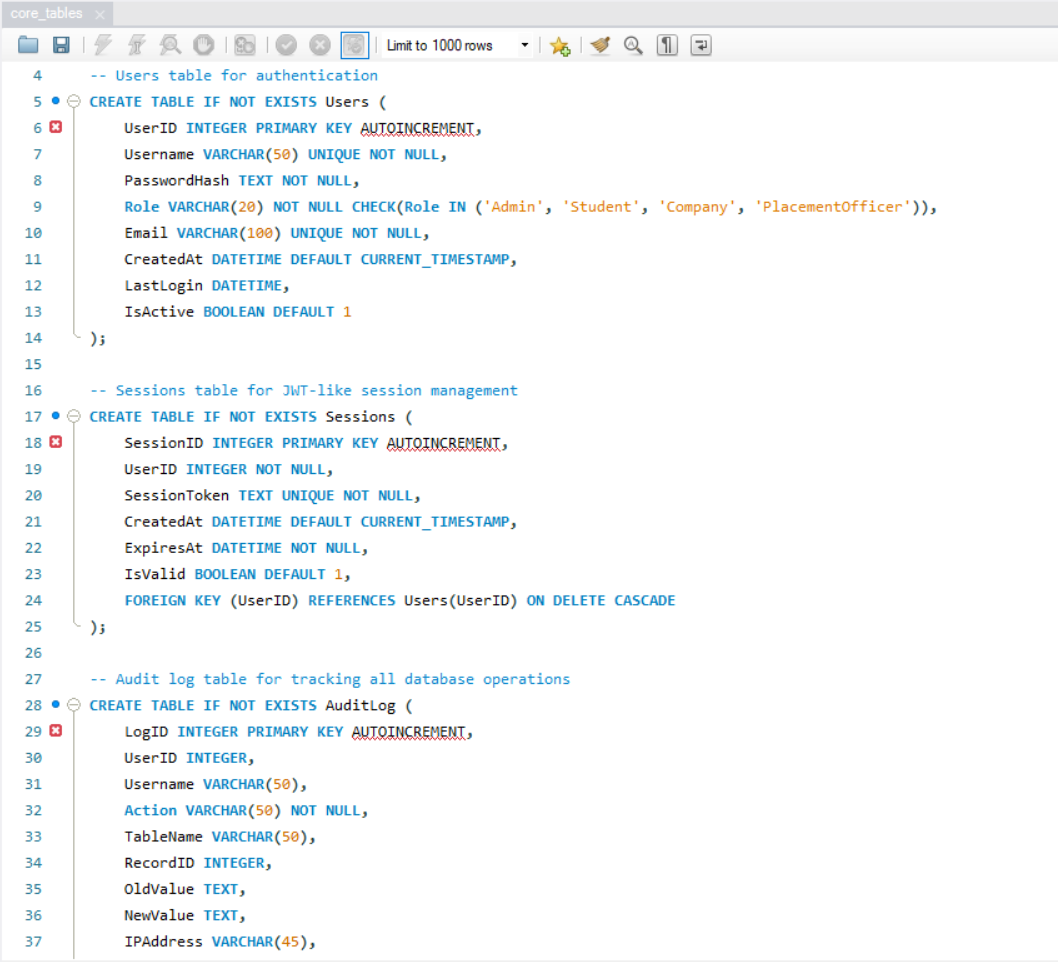

## 3. Security Framework & Audit Logging
Handling sensitive student academic records and placement data requires strict security measures. We engineered a dual-layer security protocol:

### Role-Based Access Control (RBAC)
User sessions are strictly managed. Roles (`Admin`, `Placement Officer`, `Student`) dictate UI rendering and endpoint access. If a student attempts to access an admin-only API route, the system safely intercepts and redirects the request.

### The `audit.py` Interceptor
To guarantee system accountability, we implemented a custom auditing module. Every critical system interaction is logged to a permanent, immutable audit table.
* **Tracked Metrics:** Timestamp, User ID, Target Endpoint, and Action Result.

[📸 INSERT PHOTO: A screenshot of the VS Code terminal showing live server logs and the "LOGIN REQUEST RECEIVED" or Audit interceptor output]

---

![Screenshot 2026-03-22 163958.png](<attachment:Screenshot 2026-03-22 163958.png>)
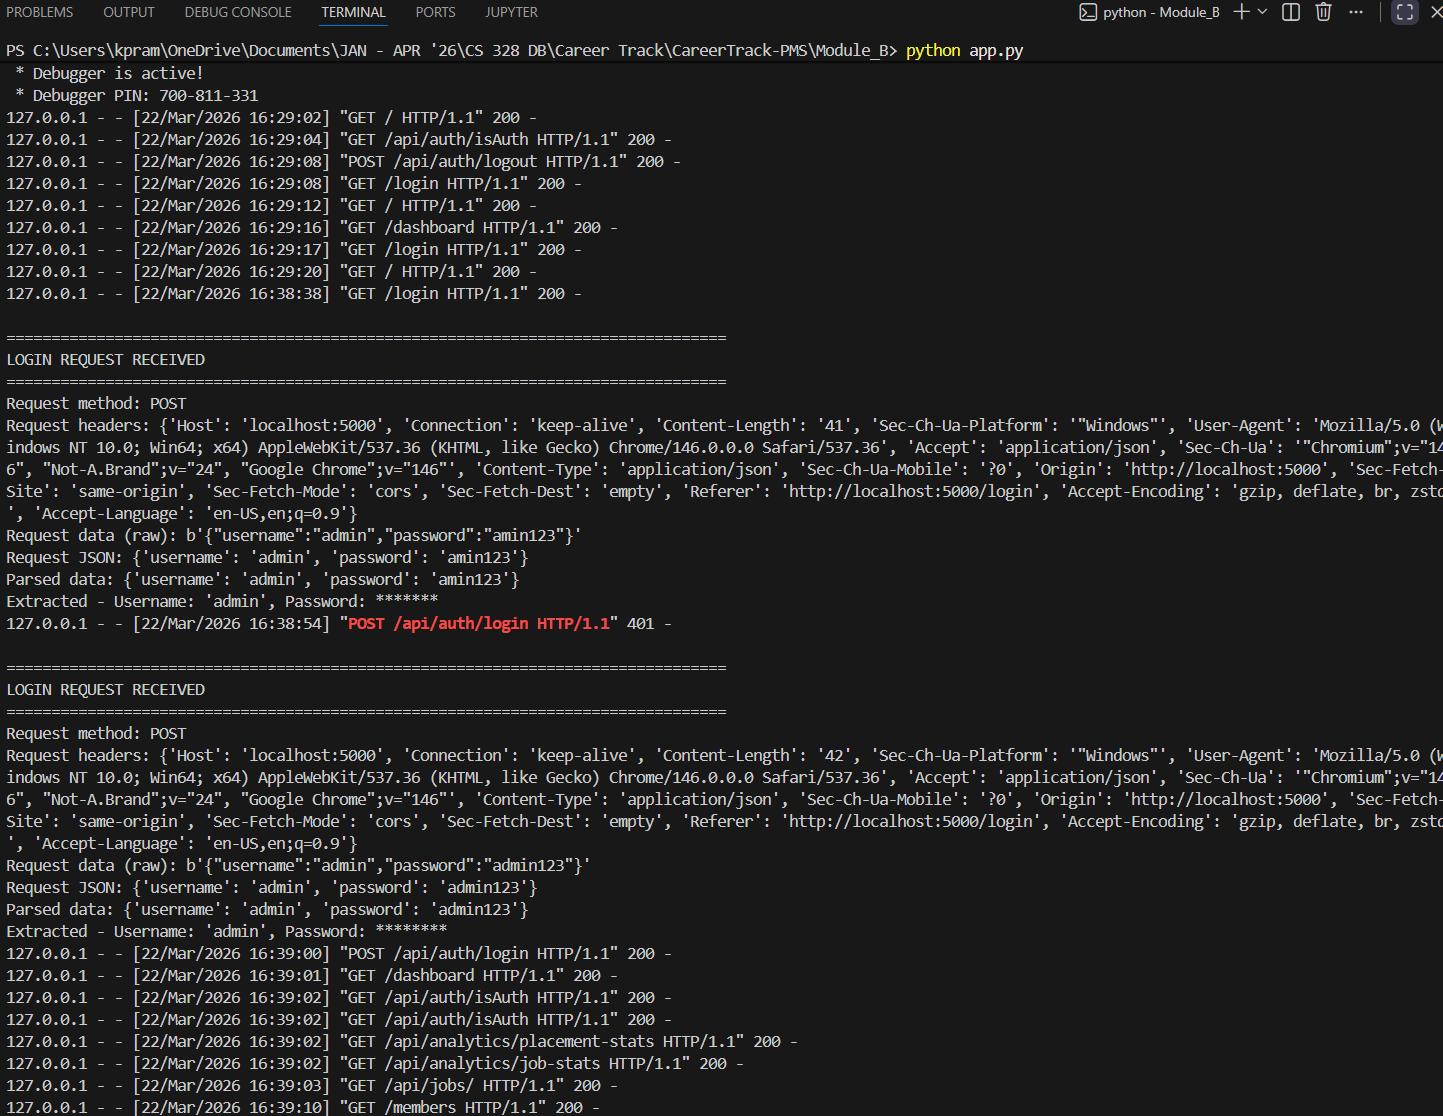


## 4. Performance Optimization: The Indexing Proof
A core objective of Assignment 2 was bridging the theoretical mechanics of our Module A storage engine with our Module B relational database. 

To prove that our SQLite database achieves the $O(\log N)$ performance established in Module A, we conducted a benchmark using the `EXPLAIN QUERY PLAN` command to observe the execution strategy.



![Screenshot 2026-03-22 164152.png](<attachment:Screenshot 2026-03-22 164152.png>)
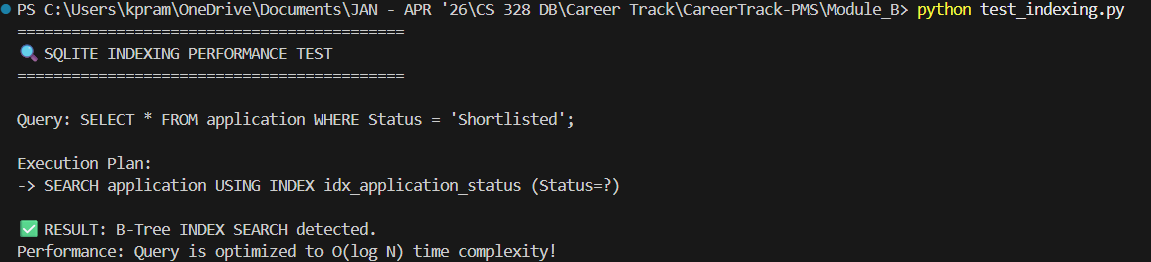

**Conclusion of Benchmark:**
Before applying our indexing script, the database utilized a full-table sequential **SCAN**—an $O(N)$ operation. By enforcing `indexes.sql`, we successfully converted these queries into B-Tree **SEARCHES**. This optimization drops query latency to $O(\log N)$, ensuring the CareerTrack system remains highly performant even as the student and application datasets scale.

---

## 5. Tools and External Sources Used
* **Languages:** Python, SQL, HTML, CSS.
* **Frameworks & Libraries:** Flask (Web Server), SQLite3 (Database Engine), Werkzeug (Security/Password Hashing).
* **External Sources:** Standard documentation for Python 3 and Flask.